# Poisson Regression

## Data Preperation for Poisson Regression Model

### Loading

In [37]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime,timedelta
import pandas.api.types as ptypes

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan

In [38]:
status_final = pd.read_csv(r"C:\Users\etaiw\Desktop\Projects\aviya_project\Data\Clean Data\Assign to Parking Lots Data\merged_parking_data_2023_2025.csv")
weather_original = pd.read_csv(r"C:\Users\etaiw\Desktop\Projects\aviya_project\Data\Clean Data\Final Weather\merged_weather_data_2023_2025.csv")

trips = status_final
weather = weather_original

In [39]:
print("STEP 0 - DataFrames loaded:")
print("trips shape:", trips.shape)
print("weather shape:", weather.shape)

STEP 0 - DataFrames loaded:
trips shape: (22827, 18)
weather shape: (3986, 13)


### STEP 1 - Prepare trips data at hourly resolution

In [40]:
# =========================================================
# STEP 1 - Prepare trips data at hourly resolution
# =========================================================

# 1.1 Ensure start_time is datetime
trips['start_time'] = pd.to_datetime(trips['start_time'], errors='coerce')

# 1.2 Keep only trip_start events (if the column exists)
if 'event_types' in trips.columns:
    trips_start_hr = trips[trips['event_types'] == 'trip_start'].copy()
else:
    trips_start_hr = trips.copy()

# 1.3 Floor to hour → this will be the time key for merging with weather
trips_start_hr['datetime_hour'] = trips_start_hr['start_time'].dt.floor('H')
trips_start_hr['date'] = trips_start_hr['datetime_hour'].dt.date
trips_start_hr['hour'] = trips_start_hr['datetime_hour'].dt.hour  # 0..23

print("\nSTEP 1 - trips_start_hr with datetime_hour/date/hour (sample):")
display(trips_start_hr[['start_time', 'datetime_hour', 'date', 'hour']].head())


STEP 1 - trips_start_hr with datetime_hour/date/hour (sample):


C:\Users\etaiw\AppData\Local\Temp\ipykernel_13880\3045977678.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trips_start_hr['datetime_hour'] = trips_start_hr['start_time'].dt.floor('H')


,start_time,datetime_hour,date,hour
2,2023-02-05 18:24:34,2023-02-05 18:00:00,2023-02-05,18
4,2023-02-08 17:46:06,2023-02-08 17:00:00,2023-02-08,17
6,2023-02-20 19:14:20,2023-02-20 19:00:00,2023-02-20,19
8,2023-02-01 16:23:19,2023-02-01 16:00:00,2023-02-01,16
9,2023-02-07 22:59:40,2023-02-07 22:00:00,2023-02-07,22


### STEP 2 - Aggregate trips to trips_per_hour (target y)

In [41]:
# =========================================================
# STEP 2A - Prepare hourly weather from raw weather_original
# =========================================================

# Start from the original clean weather dataframe
weather = weather_original.copy()

# Make sure 'datetime' is really datetime dtype
weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce')

# Floor to hour resolution
weather['datetime_hour'] = weather['datetime'].dt.floor('H')

# Aggregate to hourly weather
hourly_weather = (
    weather
      .groupby('datetime_hour')
      .agg(
          temp_c      = ('temp_c', 'mean'),
          temp_max_c  = ('temp_max_c', 'mean'),
          temp_min_c  = ('temp_min_c', 'mean'),
          wind_speed_ms = ('wind_speed_ms', 'mean'),
          rain_mm     = ('rain_mm', 'sum'),
      )
      .reset_index()
)

print("\nSTEP 2A - hourly_weather (first rows):")
display(hourly_weather.head())
print("\nSTEP 2A - hourly_weather shape:", hourly_weather.shape)



STEP 2A - hourly_weather (first rows):


C:\Users\etaiw\AppData\Local\Temp\ipykernel_13880\2694457965.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  weather['datetime_hour'] = weather['datetime'].dt.floor('H')


,datetime_hour,temp_c,temp_max_c,temp_min_c,wind_speed_ms,rain_mm
0,2023-02-01 00:00:00,14.233333,15.15,13.25,10.316667,3.5
1,2023-02-01 01:00:00,15.266667,15.65,14.75,11.383333,0.6
2,2023-02-01 02:00:00,15.366667,15.60,15.00,10.216667,0.0
3,2023-02-01 03:00:00,14.450000,15.20,13.95,5.983333,0.0
4,2023-02-01 04:00:00,16.016667,16.15,15.55,8.266667,0.0



STEP 2A - hourly_weather shape: (1994, 6)


In [42]:
# =========================================================
# STEP 2B - Aggregate trips to trips_per_hour (target y)
# =========================================================

hourly_trips = (
    trips_start_hr
    .groupby('datetime_hour')
    .size()
    .rename('trips_per_hour')
    .reset_index()
)

print("\nSTEP 2B - hourly_trips (first rows):")
display(hourly_trips.head())

print("\nSTEP 2B - hourly_trips shape:", hourly_trips.shape)
print("\nSTEP 2B - trips_per_hour summary:")
display(hourly_trips['trips_per_hour'].describe().to_frame(name='trips_per_hour_stats'))



STEP 2B - hourly_trips (first rows):


,datetime_hour,trips_per_hour
0,2023-02-01 00:00:00,1
1,2023-02-01 08:00:00,1
2,2023-02-01 09:00:00,2
3,2023-02-01 10:00:00,2
4,2023-02-01 11:00:00,3



STEP 2B - hourly_trips shape: (1536, 2)

STEP 2B - trips_per_hour summary:


,trips_per_hour_stats
count,1536.000000
mean,6.250000
std,5.481387
min,1.000000
25%,2.000000
50%,5.000000
75%,9.000000
max,35.000000


### STEP 3 - Build full hourly panel and merge trips (with interpolation time based)

In [43]:
# =========================================================
# STEP 3 - Build full hourly panel and merge trips (with interpolation)
#   FIX: do NOT create a continuous pd.date_range(min,max) across multi-year gaps.
#        Instead, build the panel from OBSERVED weather hours.
# =========================================================
# Interpolation = fills missing or intermediate values by estimating them from surrounding data points

from IPython.display import display

# 3.1 Build hourly panel from observed weather hours (no fake months/years)
#     Use hourly_weather because it's already at hourly resolution.
reg_hourly = (
    hourly_weather[['datetime_hour']]
    .drop_duplicates()
    .sort_values('datetime_hour')
    .reset_index(drop=True)
)

print("\nSTEP 3 - observed weather hours created:")
print(reg_hourly.shape)
display(reg_hourly.head(10))

# 3.2 Merge hourly trips (NaN → 0 trips)
reg_hourly = reg_hourly.merge(hourly_trips, on='datetime_hour', how='left')
reg_hourly['trips_per_hour'] = reg_hourly['trips_per_hour'].fillna(0).astype(int)

# 3.3 Merge hourly weather (NaNs to be interpolated if any)
reg_hourly = reg_hourly.merge(hourly_weather, on='datetime_hour', how='left')

print("\nSTEP 3 - before interpolation (check NaNs):")
display(reg_hourly.isna().sum().to_frame('n_missing'))

# 3.4 Interpolate missing weather columns over time (kept as you requested)
reg_hourly = reg_hourly.sort_values('datetime_hour').set_index('datetime_hour')
weather_cols = ['temp_c', 'temp_max_c', 'temp_min_c', 'wind_speed_ms', 'rain_mm']

reg_hourly[weather_cols] = reg_hourly[weather_cols].interpolate(
    method='time',
    limit_direction='both'
)

# 3.5 Back to normal index and sanity check for hourly gaps
reg_hourly = reg_hourly.reset_index()

print("\nSTEP 3 - after interpolation (check gaps):")
reg_hourly['delta'] = reg_hourly['datetime_hour'].diff().dt.total_seconds() / 3600
print(reg_hourly['delta'].value_counts().head(10))

print("\nSTEP 3 - Sample of datetime_hour + trips_per_hour:")
display(reg_hourly[['datetime_hour', 'trips_per_hour']].head(24))



STEP 3 - observed weather hours created:
(1994, 1)


,datetime_hour
0,2023-02-01 00:00:00
1,2023-02-01 01:00:00
2,2023-02-01 02:00:00
3,2023-02-01 03:00:00
4,2023-02-01 04:00:00
5,2023-02-01 05:00:00
6,2023-02-01 06:00:00
7,2023-02-01 07:00:00
8,2023-02-01 08:00:00
9,2023-02-01 09:00:00



STEP 3 - before interpolation (check NaNs):


,n_missing
datetime_hour,0
trips_per_hour,0
temp_c,0
temp_max_c,0
temp_min_c,0
wind_speed_ms,0
rain_mm,0



STEP 3 - after interpolation (check gaps):
delta
1.0       1991
8112.0       1
8089.0       1
Name: count, dtype: int64

STEP 3 - Sample of datetime_hour + trips_per_hour:


,datetime_hour,trips_per_hour
0,2023-02-01 00:00:00,1
1,2023-02-01 01:00:00,0
2,2023-02-01 02:00:00,0
3,2023-02-01 03:00:00,0
4,2023-02-01 04:00:00,0
5,2023-02-01 05:00:00,0
6,2023-02-01 06:00:00,0
7,2023-02-01 07:00:00,0
8,2023-02-01 08:00:00,1
9,2023-02-01 09:00:00,2


### STEP 4 - Add weekday (int), weekday_name, weekend (0/1)

In [44]:
# =========================================================
# STEP 4 - Add weekday (Sunday=0), weekend, weekday_name
# =========================================================

# Python weekday: Monday=0, Sunday=6
python_weekday_hr = reg_hourly['datetime_hour'].dt.weekday

# Custom weekday: Sunday=0, Monday=1, ..., Saturday=6
reg_hourly['weekday'] = (python_weekday_hr + 1) % 7

# Weekend in Israel: Friday (5) and Saturday (6) in this coding
reg_hourly['is_weekend'] = reg_hourly['weekday'].isin([5, 6]).astype(int)

# Human-readable weekday name
reg_hourly['weekday_name'] = reg_hourly['datetime_hour'].dt.day_name()

print("\nSTEP 4 - weekday (Sunday=0), is_weekend, weekday_name (sample):")
display(reg_hourly[['datetime_hour', 'weekday', 'weekday_name', 'is_weekend']].head())



STEP 4 - weekday (Sunday=0), is_weekend, weekday_name (sample):


,datetime_hour,weekday,weekday_name,is_weekend
0,2023-02-01 00:00:00,3,Wednesday,0
1,2023-02-01 01:00:00,3,Wednesday,0
2,2023-02-01 02:00:00,3,Wednesday,0
3,2023-02-01 03:00:00,3,Wednesday,0
4,2023-02-01 04:00:00,3,Wednesday,0


### STEP 4.5 — Justify focusing on weekdays (Sun–Thu) vs weekends (Fri–Sat)

In [45]:
# =========================================================
# STEP 4.5 — Justify focusing on weekdays (Sun–Thu) vs weekends (Fri–Sat)
# =========================================================

def null_dispersion(df_in):
    y = df_in["trips_per_hour"].astype(int)
    X = pd.DataFrame({"Intercept": np.ones(len(df_in))}, index=df_in.index)
    res = sm.GLM(y, X, family=sm.families.Poisson()).fit(cov_type="HC0")
    disp = (res.resid_pearson**2).sum() / res.df_resid
    return {
        "N_hours": len(df_in),
        "mean_trips_hr": float(y.mean()),
        "var_trips_hr": float(y.var()),
        "disp_null": float(disp),
    }

all_df = reg_hourly.copy()
weekdays_df = all_df[all_df["is_weekend"] == 0].copy()
weekends_df = all_df[all_df["is_weekend"] == 1].copy()

summary = pd.DataFrame({
    "all": null_dispersion(all_df),
    "weekdays (Sun–Thu)": null_dispersion(weekdays_df),
    "weekends (Fri–Sat)": null_dispersion(weekends_df),
}).T

print("\nSTEP 4.5A — Descriptive comparison (null Poisson benchmark):")
display(summary)

# ---- Model-based check: does weekend still matter after controlling for time-of-day? ----
# Use your existing hour segmentation mapping if already defined; otherwise create a simple hour column now.
if "hour" not in reg_hourly.columns:
    reg_hourly["hour"] = reg_hourly["datetime_hour"].dt.hour.astype(int)

# IMPORTANT: if you already built hour_to_seg from the weekday model, reuse it here:
# hour_to_seg should exist (from your K=10 segmentation step). If not, skip this part for now.

if "hour_to_seg" in globals():
    reg_hourly["hour_segment_10"] = reg_hourly["hour"].map(hour_to_seg).astype(int)

    y_all = reg_hourly["trips_per_hour"].astype(int)
    hseg_all = pd.get_dummies(reg_hourly["hour_segment_10"], prefix="hseg", drop_first=True)

    X_weekend = pd.concat([hseg_all, reg_hourly[["is_weekend"]].astype(float)], axis=1)
    X_weekend = sm.add_constant(X_weekend, has_constant="add").astype(float)

    res_weekend = sm.GLM(y_all, X_weekend, family=sm.families.Poisson()).fit(cov_type="HC0")

    beta_w = float(res_weekend.params["is_weekend"])
    irr_w = float(np.exp(beta_w))

    print("\nSTEP 4.5B — Model-based check (controls for hour segments):")
    print("IRR(is_weekend) =", round(irr_w, 3), "| beta =", round(beta_w, 4))

    print("is_weekend coef:", float(res_weekend.params["is_weekend"]))
    print("is_weekend robust SE:", float(res_weekend.bse["is_weekend"]))
    print("is_weekend p-value:", float(res_weekend.pvalues["is_weekend"]))

else:
    print("\nSTEP 4.5B skipped: hour_to_seg not defined yet (run after hour segmentation is created).")



STEP 4.5A — Descriptive comparison (null Poisson benchmark):


,N_hours,mean_trips_hr,var_trips_hr,disp_null
all,1994.0,4.696088,29.881500,6.363062
weekdays (Sun–Thu),1441.0,5.501735,35.625171,6.475261
weekends (Fri–Sat),553.0,2.596745,8.842526,3.405234



STEP 4.5B — Model-based check (controls for hour segments):
IRR(is_weekend) = 0.472 | beta = -0.7502
is_weekend coef: -0.7502372209505931
is_weekend robust SE: 0.056080177520131815
is_weekend p-value: 8.137202669012947e-41


### STEP 5 - Define flexible time-of-day segments (Legacy)

In [46]:
# =========================================================
# STEP 5 - Create time-of-day segments and dummies
# =========================================================
# Update HERE for different time slots

from IPython.display import display

# 5.0 Make sure 'hour' column exists
if 'hour' not in reg_hourly.columns:
    reg_hourly['hour'] = reg_hourly['datetime_hour'].dt.hour

print("STEP 5 - Hour column check:")
print(reg_hourly[['datetime_hour', 'hour']].head())

# 5.1 Remove old TOD columns if they exist
cols_to_drop = [c for c in reg_hourly.columns if c.startswith('tod_')] + ['tod_segment']
if cols_to_drop:
    reg_hourly = reg_hourly.drop(columns=cols_to_drop, errors='ignore')

# 5.2 Define logical time-of-day mapping
# Night is one continuous logical category: 20:00–24:00 AND 00:00–07:00
def map_tod(hour):
    # night: 20:00–24:00 or 00:00–07:00
    if (hour >= 20) or (hour < 7):
        return 'night'
    # morning: 07:00–10:00
    elif 7 <= hour < 10:
        return 'morning'
    # afternoon (day): 10:00–16:00
    elif 10 <= hour < 16:
        return 'afternoon'
    # evening: 16:00–20:00
    else:  # 16 <= hour < 20
        return 'evening'

reg_hourly['tod_segment'] = reg_hourly['hour'].apply(map_tod)

# 5.3 Ensure categorical type with explicit order so that
# 'night' is the baseline when we create dummies (drop_first=True)
tod_cat_type = pd.api.types.CategoricalDtype(
    categories=['night', 'morning', 'afternoon', 'evening'],
    ordered=True
)
reg_hourly['tod_segment'] = reg_hourly['tod_segment'].astype(tod_cat_type)

print("\nSTEP 5 - tod_segment created (night = 20:00–07:00):")
display(reg_hourly[['datetime_hour', 'hour', 'tod_segment']].head())


STEP 5 - Hour column check:
        datetime_hour  hour
0 2023-02-01 00:00:00     0
1 2023-02-01 01:00:00     1
2 2023-02-01 02:00:00     2
3 2023-02-01 03:00:00     3
4 2023-02-01 04:00:00     4

STEP 5 - tod_segment created (night = 20:00–07:00):


,datetime_hour,hour,tod_segment
0,2023-02-01 00:00:00,0,night
1,2023-02-01 01:00:00,1,night
2,2023-02-01 02:00:00,2,night
3,2023-02-01 03:00:00,3,night
4,2023-02-01 04:00:00,4,night


### STEP 6 - Create dummy variables for weekday and TOD segments (Legacy)

#### 6.0 - Create weekday dummy variables

In [47]:
# =========================================================
# STEP 6.0 - Choose subset for modeling and create weekday dummies
# =========================================================
# weekday coding in this notebook: Sunday=0 ... Saturday=6

MODE_FOR_MAIN_MODEL = "weekdays"  # options: "all", "weekdays", "weekends"

def subset_by_mode(df, mode):
    if mode == "all":
        return df.copy()
    if mode == "weekdays":
        return df[df["weekday"].isin([0, 1, 2, 3, 4])].copy()   # Sun–Thu
    if mode == "weekends":
        return df[df["weekday"].isin([5, 6])].copy()           # Fri–Sat
    raise ValueError("mode must be one of: all, weekdays, weekends")

reg_model = subset_by_mode(reg_hourly, MODE_FOR_MAIN_MODEL).copy()
reg_model["hour"] = reg_model["datetime_hour"].dt.hour

# Keep reg_wd as an alias so downstream cells that expect reg_wd won't break
reg_wd = reg_model

# Weekday dummies (Sunday baseline via drop_first)
wd_dummy_cols = pd.get_dummies(reg_model["weekday"], prefix="wd", drop_first=True)

print("MODE_FOR_MAIN_MODEL:", MODE_FOR_MAIN_MODEL)
print("reg_model shape:", reg_model.shape)
print("wd_dummy_cols shape:", wd_dummy_cols.shape)
display(wd_dummy_cols.head())


MODE_FOR_MAIN_MODEL: weekdays
reg_model shape: (1441, 14)
wd_dummy_cols shape: (1441, 4)


,wd_1,wd_2,wd_3,wd_4
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False


#### 6.1 - Create TOD (Time Of Day Segment) dummy variables

In [48]:
# =========================================================
# STEP 6.1 - Create TOD (Time Of Day Segment) dummy variables (BASELINE)
# =========================================================
# 4-bin TOD scheme (edit cutoffs if you used different ones in your thesis)
reg_model["tod_segment"] = pd.cut(
    reg_model["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

tod_dummy_cols = pd.get_dummies(reg_model["tod_segment"], prefix="tod", drop_first=True)

print("TOD dummy columns created:", tod_dummy_cols.columns.tolist())
print("tod_dummy_cols shape:", tod_dummy_cols.shape)
display(tod_dummy_cols.head())


TOD dummy columns created: ['tod_morning', 'tod_afternoon', 'tod_evening']
tod_dummy_cols shape: (1441, 3)


,tod_morning,tod_afternoon,tod_evening
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


#### 6.2 - Build feature list (X&Y)

In [49]:
# =========================================================
# STEP 6.2 - Build feature matrices (X) and target (y)
# =========================================================

# Choose weather columns that exist in your panel
# In the baseline there should be no "rain_mm"
weather_cols = [c for c in ["temp_c", "wind_speed_ms"] if c in reg_model.columns]
print("Weather columns used:", weather_cols)

y_hr = reg_model["trips_per_hour"]

# Baseline X: TOD + weekday + weather
X_baseline = pd.concat([tod_dummy_cols, wd_dummy_cols, reg_model[weather_cols]], axis=1)
X_baseline = sm.add_constant(X_baseline, has_constant="add")

# Optimized X: Hour fixed effects + weekday + weather
hour_dummy_cols = pd.get_dummies(reg_model["hour"], prefix="hour", drop_first=True)
X_hourFE = pd.concat([hour_dummy_cols, wd_dummy_cols, reg_model[weather_cols]], axis=1)
X_hourFE = sm.add_constant(X_hourFE, has_constant="add")

print("X_baseline shape:", X_baseline.shape)
print("X_hourFE shape:", X_hourFE.shape)
print("y_hr shape:", y_hr.shape)


Weather columns used: ['temp_c', 'wind_speed_ms']
X_baseline shape: (1441, 10)
X_hourFE shape: (1441, 30)
y_hr shape: (1441,)


#### 6.3 - FIX v2: Clean features (drop non-numeric / all-NaN columns)

In [50]:
# =========================================================
# STEP 6.3 - Clean features (force numeric, fill NaNs)
# =========================================================

def clean_X(X: pd.DataFrame) -> pd.DataFrame:
    Xc = X.copy()
    Xc = Xc.apply(pd.to_numeric, errors="coerce")
    Xc = Xc.fillna(0)
    return Xc.astype(float)

X_baseline_clean = clean_X(X_baseline)
X_hourFE_clean   = clean_X(X_hourFE)

# Keep names used later in the notebook
X_hr = X_hourFE_clean

print("Cleaned shapes:")
print("X_baseline_clean:", X_baseline_clean.shape)
print("X_hourFE_clean:", X_hourFE_clean.shape)
display(X_hourFE_clean.head())


Cleaned shapes:
X_baseline_clean: (1441, 10)
X_hourFE_clean: (1441, 30)


,const,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,...,hour_20,hour_21,hour_22,hour_23,wd_1,wd_2,wd_3,wd_4,temp_c,wind_speed_ms
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.233333,10.316667
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.266667,11.383333
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.366667,10.216667
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.450000,5.983333
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.016667,8.266667


## Poisson Models

### Baseline Model 0 — Null (Intercept-only) on Weekdays

In [51]:
# =========================================================
# BASELINE MODEL 0 — Null (Intercept-only) on WEEKDAYS
# =========================================================

# Assumes you already have:
#   reg_model = subset_by_mode(reg_hourly, "weekdays").copy()
# and trips_per_hour exists in reg_model

y_hr = reg_model["trips_per_hour"].astype(int)

# Intercept-only design matrix
X_null = pd.DataFrame({"Intercept": np.ones(len(reg_model))}, index=reg_model.index)

poisson_null_robust = sm.GLM(y_hr, X_null, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_null = (poisson_null_robust.resid_pearson**2).sum() / poisson_null_robust.df_resid

print("\nBASELINE (Null) Poisson with Robust SE (HC0) — WEEKDAYS ONLY")
print(poisson_null_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_null:.3f}")

# Keep reference if you want to compare later
dispersion_null = disp_null



BASELINE (Null) Poisson with Robust SE (HC0) — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1440
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6498.0
Date:                Tue, 10 Feb 2026   Deviance:                       9158.5
Time:                        01:53:01   Pearson chi2:                 9.32e+03
No. Iterations:                     5   Pseudo R-squ. (CS):         -1.332e-15
Covariance Type:                  HC0                                         
Dispersion (Pearson Chi2 / df_resid): 6.475


In [52]:
print("N (weekdays):", len(reg_model))
print("mean trips/hr:", y_hr.mean(), "var trips/hr:", y_hr.var())

N (weekdays): 1441
mean trips/hr: 5.501734906315059 var trips/hr: 35.625170599120985


### Model 1 — Add Day-of-Week FE on Weekdays

In [53]:
# =========================================================
# BASELINE MODEL 1 — Add Day-of-Week FE on WEEKDAYS (Sun–Thu)
# =========================================================

y_hr = reg_model["trips_per_hour"].astype(int)

dow_dummies = pd.get_dummies(reg_model["weekday"], prefix="dow", drop_first=True)

# Force numeric (prevents statsmodels object dtype error)
X_dow = sm.add_constant(dow_dummies, has_constant="add")
X_dow = X_dow.astype(float)

poisson_dow_robust = sm.GLM(y_hr, X_dow, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_dow = (poisson_dow_robust.resid_pearson**2).sum() / poisson_dow_robust.df_resid

print("\nBASELINE (DOW-FE) Poisson with Robust SE (HC0) — WEEKDAYS ONLY")
print(poisson_dow_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_dow:.3f}")


dispersion_dow = disp_dow



BASELINE (DOW-FE) Poisson with Robust SE (HC0) — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1436
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6485.7
Date:                Tue, 10 Feb 2026   Deviance:                       9133.8
Time:                        01:53:01   Pearson chi2:                 9.27e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01697
Covariance Type:                  HC0                                         
Dispersion (Pearson Chi2 / df_resid): 6.458


In [54]:
# Column names (see what you actually modeled)
print("Columns:", X_dow.columns.tolist())

# Check which weekdays are in the filtered dataset (should be 0..4 if weekdays only)
print("Unique weekday values in reg_model:", sorted(reg_model["weekday"].unique()))

# Dummy validity: each row should have exactly one active weekday dummy
# (if drop_first=True, then rows of the reference weekday will have all zeros)
dow_cols = [c for c in X_dow.columns if c.startswith("dow_")]

row_sums = X_dow[dow_cols].sum(axis=1)
print("Dummy row sums value counts (expect mostly 1, and some 0 for reference day):")
print(row_sums.value_counts().head(10))

Columns: ['const', 'dow_1', 'dow_2', 'dow_3', 'dow_4']
Unique weekday values in reg_model: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Dummy row sums value counts (expect mostly 1, and some 0 for reference day):
1.0    1153
0.0     288
Name: count, dtype: int64


### Model 2 — Add Hour FE on Weekdays

In [55]:
# =========================================================
# BASELINE MODEL 2 — Add Hour FE (Sun–Thu only)
# =========================================================

y_hr = reg_model["trips_per_hour"].astype(int)

# Hour dummies (assumes reg_model has 'hour' 0..23; if it's 'hour_cat', use that)
hour_dummies = pd.get_dummies(reg_model["hour"], prefix="hour", drop_first=True)

# Combine: const + DOW + Hour FE
X_time = pd.concat([dow_dummies, hour_dummies], axis=1)
X_time = sm.add_constant(X_time, has_constant="add").astype(float)

poisson_time_robust = sm.GLM(y_hr, X_time, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_time = (poisson_time_robust.resid_pearson**2).sum() / poisson_time_robust.df_resid

print("\nBASELINE (DOW + Hour-FE) Poisson with Robust SE (HC0) — WEEKDAYS ONLY")
print(poisson_time_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_time:.3f}")

dispersion_time = disp_time



BASELINE (DOW + Hour-FE) Poisson with Robust SE (HC0) — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1413
Model Family:                 Poisson   Df Model:                           27
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3041.5
Date:                Tue, 10 Feb 2026   Deviance:                       2245.4
Time:                        01:53:01   Pearson chi2:                 2.39e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.9917
Covariance Type:                  HC0                                         
Dispersion (Pearson Chi2 / df_resid): 1.689


In [56]:
print("Columns:", X_time.columns.tolist())
print("Dtypes unique:", X_time.dtypes.unique())

# How many DOW and Hour columns?
dow_cols = [c for c in X_time.columns if c.startswith("dow_")]
hour_cols = [c for c in X_time.columns if c.startswith("hour_")]
print(f"#dow dummies: {len(dow_cols)} | #hour dummies: {len(hour_cols)}")
print("DOW columns:", dow_cols)
print("Hour columns sample:", hour_cols[:8], "...", hour_cols[-3:])

# Dummy validity checks
print("\nDOW dummy row sums (expect 0 or 1):")
print(X_time[dow_cols].sum(axis=1).value_counts().head(5))

print("\nHour dummy row sums (expect 0 or 1):")
print(X_time[hour_cols].sum(axis=1).value_counts().head(5))


Columns: ['const', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23']
Dtypes unique: [dtype('float64')]
#dow dummies: 4 | #hour dummies: 23
DOW columns: ['dow_1', 'dow_2', 'dow_3', 'dow_4']
Hour columns sample: ['hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8'] ... ['hour_21', 'hour_22', 'hour_23']

DOW dummy row sums (expect 0 or 1):
1.0    1153
0.0     288
Name: count, dtype: int64

Hour dummy row sums (expect 0 or 1):
1.0    1380
0.0      61
Name: count, dtype: int64


### Model 3 - Post Hoc on Hour Segments on Weekdays

#### Step 3A: extract hour effects from Model 2

In [57]:
# --- Step 3A: extract hour effects from Model 2 ---
params = poisson_time_robust.params

hour_effects = pd.Series({0: 0.0})  # hour 0 is reference => effect 0
for h in range(1, 24):
    hour_effects.loc[h] = params.get(f"hour_{h}", np.nan)

hour_effects = hour_effects.sort_index()
print("Hour effects (log-scale) summary:")
display(hour_effects.to_frame("beta_hour").T)


Hour effects (log-scale) summary:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
beta_hour,0.0,-0.623967,-1.424086,-2.555488,-3.066314,-3.471779,-2.219016,-1.073884,0.0764,0.614197,...,1.386093,1.760666,1.85731,1.994169,2.01198,1.478752,1.036329,0.588664,0.32371,0.373035


#### Step 3B: Wald-based adjacent segmentation

In [58]:
# --- Step 3B : Wald-based adjacent segmentation ---

from scipy.stats import chi2

params = poisson_time_robust.params
cov = poisson_time_robust.cov_params()

def eff(h):
    return 0.0 if h == 0 else float(params.get(f"hour_{h}", 0.0))

def var_eff(h):
    return 0.0 if h == 0 else float(cov.loc[f"hour_{h}", f"hour_{h}"])

def cov_eff(h1, h2):
    if h1 == 0 or h2 == 0:
        return 0.0
    return float(cov.loc[f"hour_{h1}", f"hour_{h2}"])

def wald_p_diff(h1, h2):
    d = eff(h1) - eff(h2)
    v = var_eff(h1) + var_eff(h2) - 2 * cov_eff(h1, h2)
    if v <= 0 or np.isnan(v):
        return 0.0
    w = (d**2) / v
    return 1 - chi2.cdf(w, df=1)

def seg_representative(seg):
    hours = sorted(seg)
    vals = [(h, eff(h)) for h in hours]
    vals_sorted = sorted(vals, key=lambda x: x[1])
    return vals_sorted[len(vals_sorted)//2][0]

target_k = 10
segments = [[h] for h in range(24)]

while len(segments) > target_k:
    best_i, best_p = None, -1
    for i in range(len(segments) - 1):
        hL = seg_representative(segments[i])
        hR = seg_representative(segments[i+1])
        p = wald_p_diff(hL, hR)
        if p > best_p:
            best_p, best_i = p, i

    segments[best_i] = segments[best_i] + segments[best_i + 1]
    del segments[best_i + 1]

print("Wald-based segments:", segments)


Wald-based segments: [[0, 1], [2, 3, 4, 5, 6], [7], [8], [9, 10, 11], [12, 13, 14], [15, 16, 17, 18], [19], [20], [21, 22, 23]]


#### Step 3C: map hour -> segment id

In [59]:
# --- Step 3C: map hour -> segment id ---
hour_to_seg = {}
for j, seg in enumerate(segments):
    for h in seg:
        hour_to_seg[h] = j

reg_model["hour_segment"] = reg_model["hour"].map(hour_to_seg).astype(int)

# Build segmented hour dummies
seg_dummies = pd.get_dummies(reg_model["hour_segment"], prefix="hseg", drop_first=True)

X_seg = pd.concat([dow_dummies, seg_dummies], axis=1)
X_seg = sm.add_constant(X_seg, has_constant="add").astype(float)

poisson_seg_robust = sm.GLM(y_hr, X_seg, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_seg = (poisson_seg_robust.resid_pearson**2).sum() / poisson_seg_robust.df_resid

print("\nBASELINE (DOW + HourSeg(12)) Poisson with Robust SE (HC0) — WEEKDAYS ONLY")
print(poisson_seg_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_seg:.3f}")



BASELINE (DOW + HourSeg(12)) Poisson with Robust SE (HC0) — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1427
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3102.4
Date:                Tue, 10 Feb 2026   Deviance:                       2367.3
Time:                        01:53:01   Pearson chi2:                 2.56e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9910
Covariance Type:                  HC0                                         
Dispersion (Pearson Chi2 / df_resid): 1.797


נבחרה סגמנטציה ל־10 מקטעים מאחר והיא מהווה פשרה טובה בין פרשנות (צמצום פרמטרים) לבין איכות התאמה, כאשר מדד הדיספרסיה נשאר קרוב למודל השעה המלא

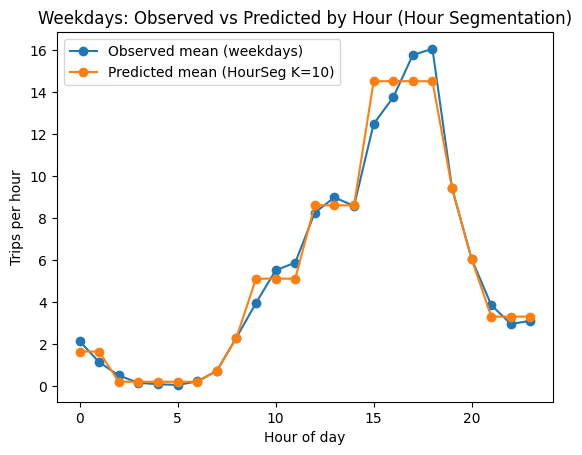

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Observed mean trips per hour (weekdays)
obs_by_hour = reg_model.groupby("hour")["trips_per_hour"].mean()

# Predicted mean per row -> average by hour
pred_m3 = poisson_seg_robust.predict(X_seg)
pred_by_hour = pd.Series(pred_m3, index=reg_model.index).groupby(reg_model["hour"]).mean()

plt.figure()
plt.plot(obs_by_hour.index, obs_by_hour.values, marker="o", label="Observed mean (weekdays)")
plt.plot(pred_by_hour.index, pred_by_hour.values, marker="o", label="Predicted mean (HourSeg K=10)")
plt.xlabel("Hour of day")
plt.ylabel("Trips per hour")
plt.title("Weekdays: Observed vs Predicted by Hour (Hour Segmentation)")
plt.legend()
plt.show()


### Model 4 — Add temp + wind (on top of DOW + HourSeg) on Weekdays

In [61]:
# =========================================================
# MODEL 4 — Add temp + wind (on top of DOW + HourSeg(10)) — WEEKDAYS ONLY
# =========================================================

y_hr = reg_model["trips_per_hour"].astype(int)

# --- hour segment dummies (K=10) ---
seg_col = "hour_segment"
seg_dummies = pd.get_dummies(reg_model[seg_col], prefix="hseg", drop_first=True)

# --- weather terms (make sure numeric) ---
weather_cols = ["temp_c", "wind_speed_ms"]  # <-- change names if needed
X_weather = reg_model[weather_cols].copy()

# coerce to numeric (avoids object dtype issues)
for c in weather_cols:
    X_weather[c] = pd.to_numeric(X_weather[c], errors="coerce")

# optional: check missingness
print("\nMODEL 4 — Missing values in weather terms:")
print(X_weather.isna().sum())

# --- design matrix: DOW + hour segments + weather ---
X_m4 = pd.concat([dow_dummies, seg_dummies, X_weather], axis=1)
X_m4 = sm.add_constant(X_m4, has_constant="add").astype(float)

# fit
poisson_m4_robust = sm.GLM(y_hr, X_m4, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_m4 = (poisson_m4_robust.resid_pearson**2).sum() / poisson_m4_robust.df_resid

print("\nMODEL 4 — (DOW + HourSeg(10) + temp + wind) Poisson with Robust SE (HC0) — WEEKDAYS ONLY")
print(poisson_m4_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_m4:.3f}")

# keep for comparison
dispersion_m4 = disp_m4



MODEL 4 — Missing values in weather terms:
temp_c           0
wind_speed_ms    0
dtype: int64

MODEL 4 — (DOW + HourSeg(10) + temp + wind) Poisson with Robust SE (HC0) — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1425
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3056.0
Date:                Tue, 10 Feb 2026   Deviance:                       2274.5
Time:                        01:53:01   Pearson chi2:                 2.46e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9916
Covariance Type:                  HC0                                         
Dispersion (Pearson Chi2 

In [62]:
print("X_m4 columns:", X_m4.shape[1])
print("Last columns:", X_m4.columns.tolist()[-5:])


X_m4 columns: 16
Last columns: ['hseg_7', 'hseg_8', 'hseg_9', 'temp_c', 'wind_speed_ms']


### Model 4A — Routine “no-rain” baseline dataset on Weekdays

In [63]:
routine_df = reg_model[reg_model["rain_mm"] == 0].copy()

y_routine = routine_df["trips_per_hour"].astype(int)
dow_routine = pd.get_dummies(routine_df["weekday"], prefix="dow", drop_first=True).astype(float)

seg_dummies_r = pd.get_dummies(routine_df["hour_segment"], prefix="hseg", drop_first=True).astype(float)

X_routine = pd.concat([dow_routine, seg_dummies_r, routine_df[["temp_c","wind_speed_ms"]].astype(float)], axis=1)
X_routine = sm.add_constant(X_routine, has_constant="add").astype(float)

res_routine = sm.GLM(y_routine, X_routine, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_routine = (res_routine.resid_pearson**2).sum()/res_routine.df_resid

print("ROUTINE (weekdays & no-rain) baseline dispersion:", round(disp_routine, 3))


ROUTINE (weekdays & no-rain) baseline dispersion: 1.711


In [64]:
routine_df = reg_model[reg_model["rain_mm"] == 0].copy()

In [65]:
N_routine = routine_df.shape[0]

### Model 4B — Binary rain on Weekdays

In [66]:
reg_model["is_rain"] = (reg_model["rain_mm"] > 0).astype(int)

X_bin = pd.concat([dow_dummies,
                   pd.get_dummies(reg_model["hour_segment"], prefix="hseg", drop_first=True),
                   reg_model[["temp_c","wind_speed_ms","is_rain"]].astype(float)],
                  axis=1)
X_bin = sm.add_constant(X_bin, has_constant="add").astype(float)

res_bin = sm.GLM(y_hr, X_bin, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_bin = (res_bin.resid_pearson**2).sum()/res_bin.df_resid

beta = res_bin.params["is_rain"]
print("Binary rain IRR:", float(np.exp(beta)), "beta:", float(beta), "disp:", float(disp_bin))


Binary rain IRR: 0.6523642881459307 beta: -0.42715214893350645 disp: 1.6593627975522909


### Model 5 — Add rain_mm (on top of DOW + HourSeg + temp + wind) on Weekdays

In [67]:
# =========================================================
# MODEL 5 — Add rain_mm (on top of DOW + HourSeg(10) + temp + wind) — WEEKDAYS ONLY
# =========================================================

y_hr = reg_model["trips_per_hour"].astype(int)

seg_col = "hour_segment"
seg_dummies = pd.get_dummies(reg_model[seg_col], prefix="hseg", drop_first=True)

weather_cols_m5 = ["temp_c", "wind_speed_ms", "rain_mm"]
X_weather_m5 = reg_model[weather_cols_m5].copy()

for c in weather_cols_m5:
    X_weather_m5[c] = pd.to_numeric(X_weather_m5[c], errors="coerce")

print("\nMODEL 5 — Missing values in weather terms:")
print(X_weather_m5.isna().sum())

X_m5 = pd.concat([dow_dummies, seg_dummies, X_weather_m5], axis=1)
X_m5 = sm.add_constant(X_m5, has_constant="add").astype(float)

print("X_m5 columns:", X_m5.shape[1])
print("Last columns:", X_m5.columns.tolist()[-6:])

poisson_m5_robust = sm.GLM(y_hr, X_m5, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_m5 = (poisson_m5_robust.resid_pearson**2).sum() / poisson_m5_robust.df_resid

print("\nMODEL 5 — (DOW + HourSeg(10) + temp + wind + rain) Poisson with Robust SE (HC0) — WEEKDAYS ONLY")
print(poisson_m5_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_m5:.3f}")

beta_rain = poisson_m5_robust.params["rain_mm"]
irr_rain = np.exp(beta_rain)
print(f"IRR for +1mm rain: {irr_rain:.3f} (beta={beta_rain:.4f})")



MODEL 5 — Missing values in weather terms:
temp_c           0
wind_speed_ms    0
rain_mm          0
dtype: int64
X_m5 columns: 17
Last columns: ['hseg_7', 'hseg_8', 'hseg_9', 'temp_c', 'wind_speed_ms', 'rain_mm']

MODEL 5 — (DOW + HourSeg(10) + temp + wind + rain) Poisson with Robust SE (HC0) — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1424
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3033.9
Date:                Tue, 10 Feb 2026   Deviance:                       2230.2
Time:                        01:53:01   Pearson chi2:                 2.42e+03
No. Iterations:                     7   Pseudo R-squ. (CS

### Model 6 — Replace continuous rain with rain bins on Weekdays

In [68]:
# =========================================================
# MODEL 6 — Replace continuous rain with rain bins (for interpretability + post-hoc style)
# =========================================================

y_hr = reg_model["trips_per_hour"].astype(int)

seg_col = "hour_segment"
seg_dummies = pd.get_dummies(reg_model[seg_col], prefix="hseg", drop_first=True)

# Define bins (tweak edges if you prefer)
bins = [-1e-9, 0, 0.5, 2.0, np.inf]
labels = ["0", "0-0.5", "0.5-2", "2+"]

reg_model["rain_bin"] = pd.cut(reg_model["rain_mm"], bins=bins, labels=labels)

rain_bin_dummies = pd.get_dummies(reg_model["rain_bin"], prefix="rain", drop_first=True)

X_weather_basic = reg_model[["temp_c", "wind_speed_ms"]].copy().astype(float)

X_m6 = pd.concat([dow_dummies, seg_dummies, X_weather_basic, rain_bin_dummies], axis=1)
X_m6 = sm.add_constant(X_m6, has_constant="add").astype(float)

poisson_m6_robust = sm.GLM(y_hr, X_m6, family=sm.families.Poisson()).fit(cov_type="HC0")
disp_m6 = (poisson_m6_robust.resid_pearson**2).sum() / poisson_m6_robust.df_resid

print("\nMODEL 6 — (DOW + HourSeg(10) + temp + wind + rain bins) Poisson HC0 — WEEKDAYS ONLY")
print(poisson_m6_robust.summary().tables[0])
print(f"Dispersion (Pearson Chi2 / df_resid): {disp_m6:.3f}")

# Interpret bins vs reference (rain=0 is reference if drop_first=True and labels ordered)
for c in rain_bin_dummies.columns:
    beta = poisson_m6_robust.params[c]
    irr = np.exp(beta)
    print(f"{c}: IRR={irr:.3f} (beta={beta:.4f})")



MODEL 6 — (DOW + HourSeg(10) + temp + wind + rain bins) Poisson HC0 — WEEKDAYS ONLY
                 Generalized Linear Model Regression Results                  
Dep. Variable:         trips_per_hour   No. Observations:                 1441
Model:                            GLM   Df Residuals:                     1422
Model Family:                 Poisson   Df Model:                           18
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3005.9
Date:                Tue, 10 Feb 2026   Deviance:                       2174.3
Time:                        01:53:01   Pearson chi2:                 2.34e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9921
Covariance Type:                  HC0                                         
Dispersion (Pearson Chi2 / df_resid): 1.648
rain_0-0.5: IRR=0.760 (beta=-0.2747)
rain_0.5-2: IRR=0.571 (beta=-0.5595)
rain_2+

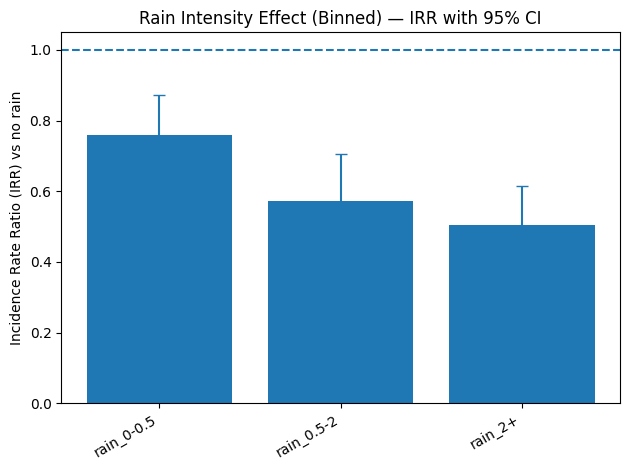

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

params = poisson_m6_robust.params
bse = poisson_m6_robust.bse  # robust SE under HC0

# Pull only rain-bin coefficients (reference is rain_bin=0)
rain_terms = [c for c in params.index if c.startswith("rain_")]

rows = []
for term in rain_terms:
    beta = float(params[term])
    se = float(bse[term])
    irr = np.exp(beta)
    lo = np.exp(beta - 1.96*se)
    hi = np.exp(beta + 1.96*se)
    rows.append([term, irr, lo, hi])

df_rain = pd.DataFrame(rows, columns=["term", "IRR", "CI_low", "CI_high"])
df_rain = df_rain.sort_values("IRR", ascending=False)  # optional ordering

plt.figure()
x = np.arange(len(df_rain))
plt.bar(x, df_rain["IRR"].values)
plt.errorbar(x, df_rain["IRR"].values,
             yerr=[df_rain["IRR"].values - df_rain["CI_low"].values,
                   df_rain["CI_high"].values - df_rain["IRR"].values],
             fmt="none", capsize=4)
plt.axhline(1.0, linestyle="--")
plt.xticks(x, df_rain["term"].values, rotation=30, ha="right")
plt.ylabel("Incidence Rate Ratio (IRR) vs no rain")
plt.title("Rain Intensity Effect (Binned) — IRR with 95% CI")
plt.tight_layout()
plt.show()


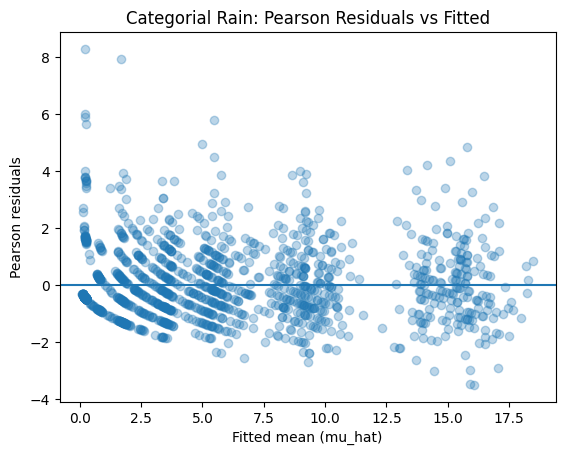

In [70]:
import numpy as np
import matplotlib.pyplot as plt

mu_hat = poisson_m6_robust.predict(X_m6)
resid_pearson = poisson_m6_robust.resid_pearson

plt.figure()
plt.scatter(mu_hat, resid_pearson, alpha=0.3)
plt.axhline(0)
plt.xlabel("Fitted mean (mu_hat)")
plt.ylabel("Pearson residuals")
plt.title("Categorial Rain: Pearson Residuals vs Fitted")
plt.show()


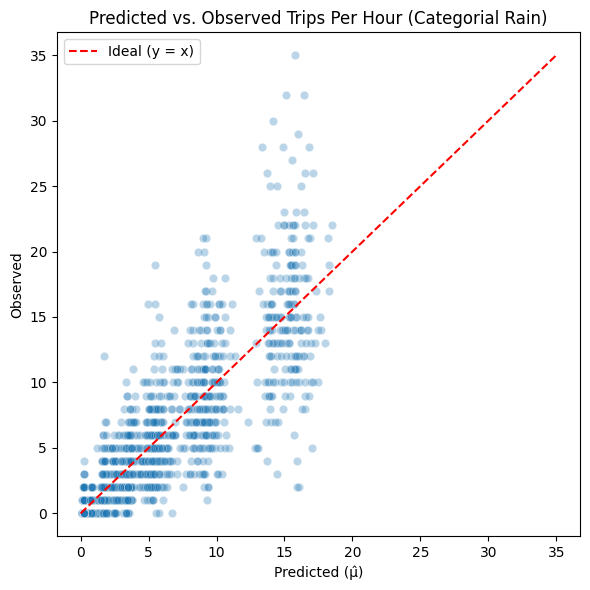

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict expected counts from Model 6
mu_hat_m6 = poisson_m6_robust.predict(X_m6)

# Add predictions to DataFrame
df_diag = reg_model.loc[reg_model['is_weekend'] == 0].copy()
df_diag["mu_hat"] = mu_hat_m6
df_diag["resid"] = df_diag["trips_per_hour"] - df_diag["mu_hat"]

# Scatter plot: Observed vs Predicted with identity line
plt.figure(figsize=(6, 6))
sns.scatterplot(x="mu_hat", y="trips_per_hour", data=df_diag, alpha=0.3)
# Plot the y=x line for reference
x_line = np.linspace(0, df_diag[["mu_hat", "trips_per_hour"]].values.max(), 100)
plt.plot(x_line, x_line, color="red", linestyle="--", label="Ideal (y = x)")
plt.title("Predicted vs. Observed Trips Per Hour (Categorial Rain)")
plt.xlabel("Predicted (μ̂)")
plt.ylabel("Observed")
plt.legend()
plt.tight_layout()
plt.show()


### Dispersion for each model table

In [72]:
import pandas as pd

model_flow_report = pd.DataFrame([
    {"Model": "Null model (weekdays)",
     "Filter": "Weekdays",
     "Terms": "Intercept",
     "N": 1441, "Dispersion": 6.475, "Key effect": ""},

    {"Model": "Day-of-week effects (weekdays)",
     "Filter": "Weekdays",
     "Terms": "DOW (Sun–Thu)",
     "N": 1441, "Dispersion": 6.458, "Key effect": ""},

    {"Model": "Hour-of-day fixed effects (benchmark)",
     "Filter": "Weekdays",
     "Terms": "DOW + Hour(0–23)",
     "N": 1441, "Dispersion": 1.689, "Key effect": ""},

    {"Model": "Hour-of-day segmentation (K=10)",
     "Filter": "Weekdays",
     "Terms": "DOW + HourSeg(K=10)",
     "N": 1441, "Dispersion": 1.797, "Key effect": ""},

    {"Model": "Time + temperature + wind",
     "Filter": "Weekdays",
     "Terms": "DOW + HourSeg(K=10) + temp + wind",
     "N": 1441, "Dispersion": 1.724, "Key effect": ""},

    {"Model": "Rain occurrence (binary)",
     "Filter": "Weekdays",
     "Terms": "DOW + HourSeg(K=10) + temp + wind + 1[rain>0]",
     "N": 1441, "Dispersion": 1.659, "Key effect": "IRR=0.652"},

    {"Model": "Rain intensity (continuous)",
     "Filter": "Weekdays",
     "Terms": "DOW + HourSeg(K=10) + temp + wind + rain_mm",
     "N": 1441, "Dispersion": 1.697, "Key effect": "IRR/mm=0.860"},

    {"Model": "Rain intensity (binned) — final model",
     "Filter": "Weekdays",
     "Terms": "DOW + HourSeg(K=10) + temp + wind + rain bins",
     "N": 1441, "Dispersion": 1.648, "Key effect": "IRR: 0.760 / 0.571 / 0.504"},

    {"Model": "Routine reference regime (weekdays, no rain)",
     "Filter": "Weekdays & rain=0",
     "Terms": "DOW + HourSeg(K=10) + temp + wind (subset: rain=0)",
     "N": 1270, "Dispersion": 1.711, "Key effect": "Routine regime benchmark"},
])

display(model_flow_report)


,Model,Filter,Terms,N,Dispersion,Key effect
0,Null model (weekdays),Weekdays,Intercept,1441,6.475,
1,Day-of-week effects (weekdays),Weekdays,DOW (Sun–Thu),1441,6.458,
2,Hour-of-day fixed effects (benchmark),Weekdays,DOW + Hour(0–23),1441,1.689,
3,Hour-of-day segmentation (K=10),Weekdays,DOW + HourSeg(K=10),1441,1.797,
4,Time + temperature + wind,Weekdays,DOW + HourSeg(K=10) + temp + wind,1441,1.724,
5,Rain occurrence (binary),Weekdays,DOW + HourSeg(K=10) + temp + wind + 1[rain>0],1441,1.659,IRR=0.652
6,Rain intensity (continuous),Weekdays,DOW + HourSeg(K=10) + temp + wind + rain_mm,1441,1.697,IRR/mm=0.860
7,Rain intensity (binned) — final model,Weekdays,DOW + HourSeg(K=10) + temp + wind + rain bins,1441,1.648,IRR: 0.760 / 0.571 / 0.504
8,"Routine reference regime (weekdays, no rain)",Weekdays & rain=0,DOW + HourSeg(K=10) + temp + wind (subset: rai...,1270,1.711,Routine regime benchmark
